# SAXS FBP Reconstruction — First Test

Tests `smartt.saxs_fbp.saxs_fbp_reconstruction` on the frogbone dataset.

**Pipeline recap**: for each target q-direction `y` on the upper hemisphere,
`NearestNeighbor.get_sub_geometry` collapses the 8 azimuthal segments into a scalar
sinogram weighted by arc-fraction. We then apply a ramp filter and backproject with
ASTRA, recovering a scalar volume `F_y(x,y,z)` — the value of the voxel sphere
function at direction `y`.

In [1]:
try:
    from mumott.data_handling import DataContainer
except:
    !sh ../scripts/setup.sh
    !pip install --upgrade coverage pytest-cov

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
import sys
sys.path.insert(0, '/myhome/smartt')

import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from mumott.data_handling import DataContainer

from smartt.saxs_fbp import (
    fibonacci_hemisphere,
    fbp_with_mumott_geometry,
    saxs_fbp_reconstruction,
)
import lovely_tensors as lt
lt.monkey_patch()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

device: cuda
GPU: NVIDIA A100 80GB PCIe


## 1. Load data

In [3]:
DATA_PATH = '/myhome/data/smartt/shared/frogbone/dataset_qbin_0009.h5'

dc = DataContainer(DATA_PATH, nonfinite_replacement_value=0)
geometry = dc.geometry

print('dc.data shape     :', dc.data.shape,       '  (N, J, K, M)')
print('dc.weights shape  :', dc.weights.shape)
print('volume_shape      :', geometry.volume_shape)
print('projection_shape  :', geometry.projection_shape)
print('probed_coords     :', geometry.probed_coordinates.vector.shape, '  (N, M, I, 3)')
print('n_projections     :', len(dc.projections))

INFO:Rotation matrices were loaded from the input file.


/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:228: DeprecationWarning: Entry name rotations is deprecated. Use inner_angle instead.
  _deprecated_key_warning('rotations')
/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:237: DeprecationWarning: Entry name tilts is deprecated. Use outer_angle instead.
  _deprecated_key_warning('tilts')
/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:247: DeprecationWarning: Entry name rot_mat is deprecated. Use rotation_matrix instead.
  _deprecated_key_warning('rot_mat')
/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:269: DeprecationWarning: Entry name offset_j is deprecated. Use j_offset instead.
  _deprecated_key_warning('offset_j')
/opt/conda/lib/python3.10/site-packages/mumott/data_handling/data_container.py:279: DeprecationWarning: Entry name offset_k is deprecated. Use k_offset instead.
  _deprecated_key_warning('offset_k'

INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
dc.data shape     : (240, 73, 100, 8)   (N, J, K, M)
dc.weights shape  : (240, 73, 100, 8)
volume_shape      : [65 82 65]
projection_shape  : [ 73 100]
probed_coords     : (240, 8, 3, 3)   (N, M, I, 3)
n_projections     : 240


data  : min=-1.658e-02  max=1.336e+05  mean=3.282e+02
weights: unique values [0. 1.]
valid pixels: 98.9%


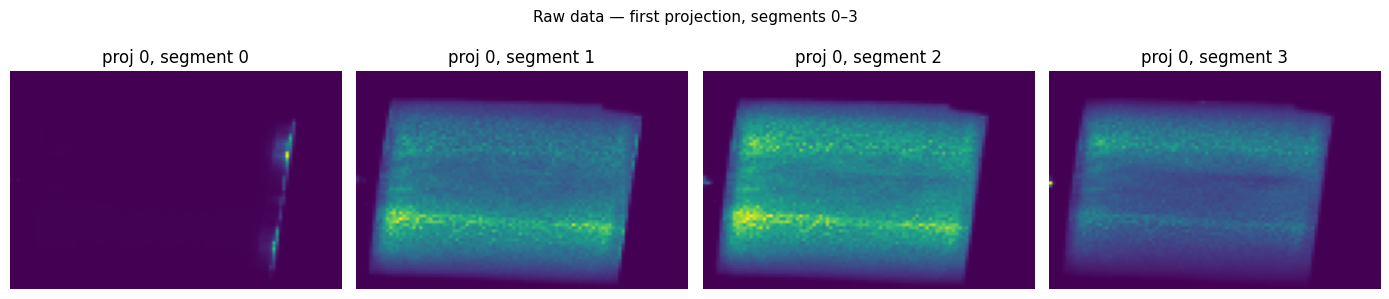

In [4]:
# Quick look at the data and weight ranges
print('data  : min={:.3e}  max={:.3e}  mean={:.3e}'.format(
    dc.data.min(), dc.data.max(), dc.data.mean()))
print('weights: unique values', np.unique(dc.weights)[:10])
print('valid pixels: {:.1f}%'.format(100 * (dc.weights > 0).mean()))

# One projection as a sanity check
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for s in range(4):
    axes[s].imshow(dc.data[0, :, :, s], aspect='auto')
    axes[s].set_title(f'proj 0, segment {s}')
    axes[s].axis('off')
plt.suptitle('Raw data — first projection, segments 0–3', fontsize=11)
plt.tight_layout()
plt.show()

## 2. Inspect q-direction grid

In [ ]:
K = 30  # number of target q-directions (keep small for first test)
y_dirs = fibonacci_hemisphere(K, half_space='y')

print(f'y_dirs shape: {y_dirs.shape}')
print(f'y range: [{y_dirs[:, 1].min():.3f}, {y_dirs[:, 1].max():.3f}]')
print(f'all unit vectors: {np.allclose(np.linalg.norm(y_dirs, axis=-1), 1.0)}')

# Plot directions on the upper hemisphere (axes swapped: display as x, z, y)
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(y_dirs[:, 0], y_dirs[:, 2], y_dirs[:, 1], c=np.arange(K), cmap='plasma', s=40)
ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y')
ax.view_init(elev=10, azim=70)
ax.set_title(f'Fibonacci hemisphere grid (K={K}, y>0 half-space)')
plt.tight_layout()
plt.show()

In [ ]:
# Beam directions in sample frame (same frame as y_dirs) — PCA of probed q-arcs
_vecs = dc.geometry.probed_coordinates.vector        # (N, M, I, 3)
_qs   = _vecs.reshape(_vecs.shape[0], -1, 3)
_qs   = _qs / np.linalg.norm(_qs, axis=-1, keepdims=True).clip(1e-10)
_cov  = np.einsum('nij,nik->njk', _qs, _qs)
_, _ev = np.linalg.eigh(_cov)
_beam = _ev[:, :, 0]                                 # smallest eigenvec = beam normal
_p0   = np.asarray(dc.geometry.p_direction_0, dtype=float)
_p0  /= np.linalg.norm(_p0)
_beam[_beam @ _p0 < 0] *= -1

# Axes swapped: display as (x, z, y) so xz plane appears horizontal
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(y_dirs[:, 0], y_dirs[:, 2], y_dirs[:, 1],
           c='steelblue', s=30, alpha=0.7, label=f'y_dirs (K={K})')
ax.scatter(_beam[:, 0], _beam[:, 2], _beam[:, 1],
           c='darkorange', s=10, alpha=0.5, label=f'beam dirs (N={len(_beam)})')
ax.set_xlabel('x'); ax.set_ylabel('z'); ax.set_zlabel('y')
ax.view_init(elev=10, azim=70)
ax.set_title('q-directions and projection beam directions — same frame')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Inspect NearestNeighbor projection matrix

Before running the full reconstruction we build `NearestNeighbor` manually
to inspect the projection matrix and understand coverage.

In [26]:
from mumott.methods.basis_sets import NearestNeighbor

nn_mumott = NearestNeighbor(
    directions=y_dirs,
    probed_coordinates=geometry.probed_coordinates,
    enforce_friedel_symmetry=True,
    integration_mode='simpson',
    integration_tolerance=1e-8,
    enforce_sparsity=False,
)

pm = nn_mumott.projection_matrix   # (N, M, K)
print(f'projection_matrix shape: {pm.shape}  (N_proj, M_segments, K_dirs)')
print(f'values > 0 per direction (min/mean/max): '
      f'{(pm > 0).sum(axis=(0,1)).min()} / '
      f'{(pm > 0).sum(axis=(0,1)).mean():.1f} / '
      f'{(pm > 0).sum(axis=(0,1)).max()}')
print('(= number of (proj, segment) pairs that contribute to each direction)')

projection_matrix shape: (240, 8, 30)  (N_proj, M_segments, K_dirs)
values > 0 per direction (min/mean/max): 86 / 130.3 / 225
(= number of (proj, segment) pairs that contribute to each direction)


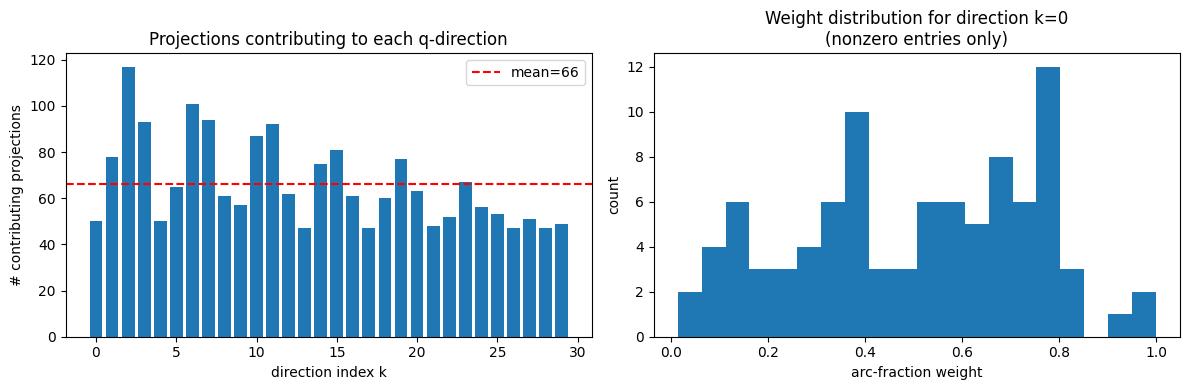


Contributing projections: min=47, mean=66.3, max=117


In [27]:
# How many projections contribute to each direction?
# A projection contributes if any of its 8 segments has pm[n, :, k] > 0.
n_contributing = np.array([
    np.sum(np.any(pm[:, :, k] > 0, axis=1))
    for k in range(K)
])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(K), n_contributing)
axes[0].set_xlabel('direction index k')
axes[0].set_ylabel('# contributing projections')
axes[0].set_title('Projections contributing to each q-direction')
axes[0].axhline(n_contributing.mean(), color='r', linestyle='--', label=f'mean={n_contributing.mean():.0f}')
axes[0].legend()

# Weight distribution for direction k=0
axes[1].hist(pm[pm[:, :, 0] > 0, 0], bins=20)
axes[1].set_xlabel('arc-fraction weight')
axes[1].set_ylabel('count')
axes[1].set_title('Weight distribution for direction k=0\n(nonzero entries only)')

plt.tight_layout()
plt.show()

print(f'\nContributing projections: min={n_contributing.min()}, '
      f'mean={n_contributing.mean():.1f}, max={n_contributing.max()}')

## 4. Run FBP reconstruction

In [ ]:
# Full reconstruction — uses the already-built nn internally (builds its own)
ball_threshold = 0.1
reconstruction, y_directions, nn = saxs_fbp_reconstruction(
    dc=dc,
    k_fibonacci=K,
    filter_type='hann',
    n_projection_samples=64,
    device=device,
    verbose=True,
    return_matrix=True,
    projection_method="ball",
    ball_threshold=ball_threshold,
    half_space='y',
)

print(f'\nreconstruction shape: {reconstruction.shape}  (K, X, Y, Z)')
print(f'value range: [{reconstruction.min():.3e}, {reconstruction.max():.3e}]')
print(f'finite values: {torch.isfinite(reconstruction).all().item()}')

In [ ]:
plt.imshow(torch.from_numpy(nn.projection_matrix).sum(dim=1).T > 0) 
plt.figure()
plt.imshow(torch.from_numpy(pm).sum(dim=1).T > 0) 

(tensor[256, 65, 82, 65] n=88691200 (0.3Gb) x∈[-882.433, 2.934e+03] μ=6.860 σ=18.753 cuda:0,
 <smartt.saxs_fbp.reconstruction.FBPProjectionMatrix at 0x75eed88d7010>)

## 5. Visualise results

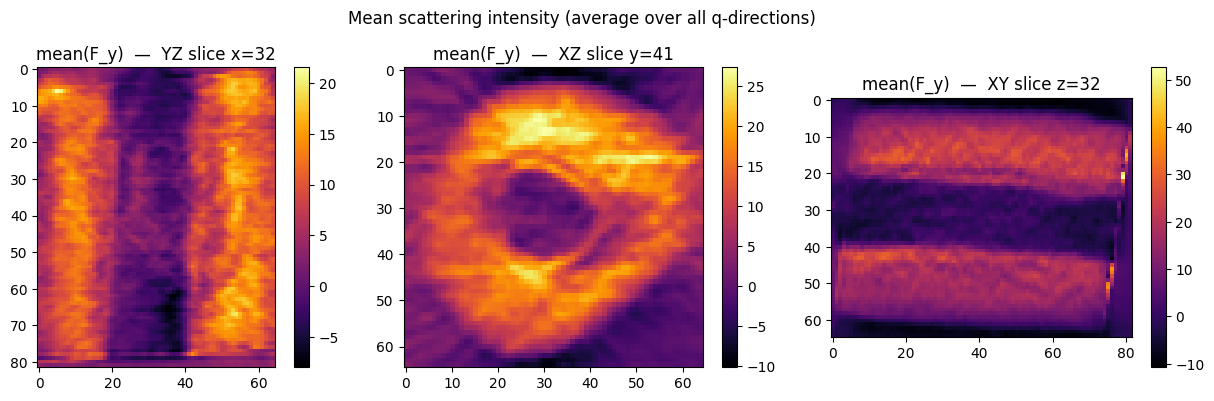

In [10]:
recon_np = reconstruction.cpu().numpy()   # (K, X, Y, Z)
X, Y, Z = recon_np.shape[1], recon_np.shape[2], recon_np.shape[3]
mid_x, mid_y, mid_z = X // 2, Y // 2, Z // 2

# --- Mean over all q-directions (should give mean scattering intensity) ---
mean_vol = recon_np.mean(axis=0)   # (X, Y, Z)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
im0 = axes[0].imshow(mean_vol[mid_x, :, :], cmap='inferno')
axes[0].set_title(f'mean(F_y)  —  YZ slice x={mid_x}')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(mean_vol[:, mid_y, :], cmap='inferno')
axes[1].set_title(f'mean(F_y)  —  XZ slice y={mid_y}')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(mean_vol[:, :, mid_z], cmap='inferno')
axes[2].set_title(f'mean(F_y)  —  XY slice z={mid_z}')
plt.colorbar(im2, ax=axes[2])

plt.suptitle('Mean scattering intensity (average over all q-directions)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import math
from matplotlib.gridspec import GridSpec

# Beam directions in the sample frame via PCA of the probed q-arcs.
# Each projection n has M*I q-direction vectors (probed_coordinates.vector).
# They all lie approximately in the plane ⊥ beam_n, so the eigenvector of the
# covariance matrix with the *smallest* eigenvalue is the beam direction.
_vecs = dc.geometry.probed_coordinates.vector          # (N, M, I, 3)
_qs   = _vecs.reshape(_vecs.shape[0], -1, 3)           # (N, M*I, 3)
_qs   = _qs / np.linalg.norm(_qs, axis=-1, keepdims=True).clip(1e-10)
_cov  = np.einsum('nij,nik->njk', _qs, _qs)           # (N, 3, 3)
_, _eigvecs = np.linalg.eigh(_cov)                     # columns sorted by ascending eigenvalue
proj_dirs   = _eigvecs[:, :, 0]                        # (N, 3) — smallest eigenvec = beam normal
_p0 = np.asarray(dc.geometry.p_direction_0, dtype=float)
_p0 /= np.linalg.norm(_p0)
proj_dirs[proj_dirs @ _p0 < 0] *= -1                  # consistent orientation with beam axis

# Exact adjacency: adj[n, k] = True if projection n contributes to direction k
adj = nn.projection_matrix.sum(axis=1) > 0            # (N, K) bool
print(f'proj_dirs shape : {proj_dirs.shape}  (N_projections, 3)')
print(f'adj shape       : {adj.shape}  (N_projections, K)')
print(f'mean contributing projections per direction: {adj.mean(axis=0).mean() * len(proj_dirs):.1f}')


def _hemisphere_ax(ax, y_dirs_arr, k_highlight, contributing=None):
    """Hemisphere context plot for direction k_highlight.

    Axes are swapped to (x, z, y) so the xz plane appears horizontal,
    matching the goniometer plotting convention.

    - Faint steelblue: all y-directions on the hemisphere.
    - Crimson point: highlighted direction y_dirs_arr[k_highlight].
    - Crimson curve: great circle {b : b · y_k = 0} in beam-direction space.
    - Darkorange solid/faint: projection beam directions, solid if contributing.
    """
    y_k = y_dirs_arr[k_highlight]

    def _s(d):
        # swap (x, y, z) → (x, z, y) for display
        return d[..., 0], d[..., 2], d[..., 1]

    # All y-directions (faint background)
    ax.scatter(*_s(y_dirs_arr), c='steelblue', s=10, alpha=0.15, depthshade=True)

    # Highlighted y-direction
    ax.scatter([y_k[0]], [y_k[2]], [y_k[1]], c='crimson', s=80, zorder=10)

    # Great circle orthogonal to y_k in beam-direction space
    perp = np.array([1.0, 0.0, 0.0]) if abs(y_k[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u = np.cross(y_k, perp); u /= np.linalg.norm(u)
    v = np.cross(y_k, u)
    t = np.linspace(0, 2 * np.pi, 300)
    gc = np.outer(np.cos(t), u) + np.outer(np.sin(t), v)  # (300, 3)
    ax.plot(gc[:, 0], gc[:, 2], gc[:, 1], c='crimson', lw=1.2, alpha=0.7)

    # Projection beam directions: solid if they contribute, faint otherwise
    close = contributing if contributing is not None else np.ones(len(proj_dirs), dtype=bool)
    if close.any():
        ax.scatter(*_s(proj_dirs[close]), c='darkorange', s=14, alpha=0.85, depthshade=False)
    if (~close).any():
        ax.scatter(*_s(proj_dirs[~close]), c='darkorange', s=8, alpha=0.1, depthshade=False)

    ax.set_xlabel('x', fontsize=6); ax.set_ylabel('z', fontsize=6); ax.set_zlabel('y', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.view_init(elev=10, azim=70)
    ax.set_title(f'k={k_highlight}', fontsize=7)

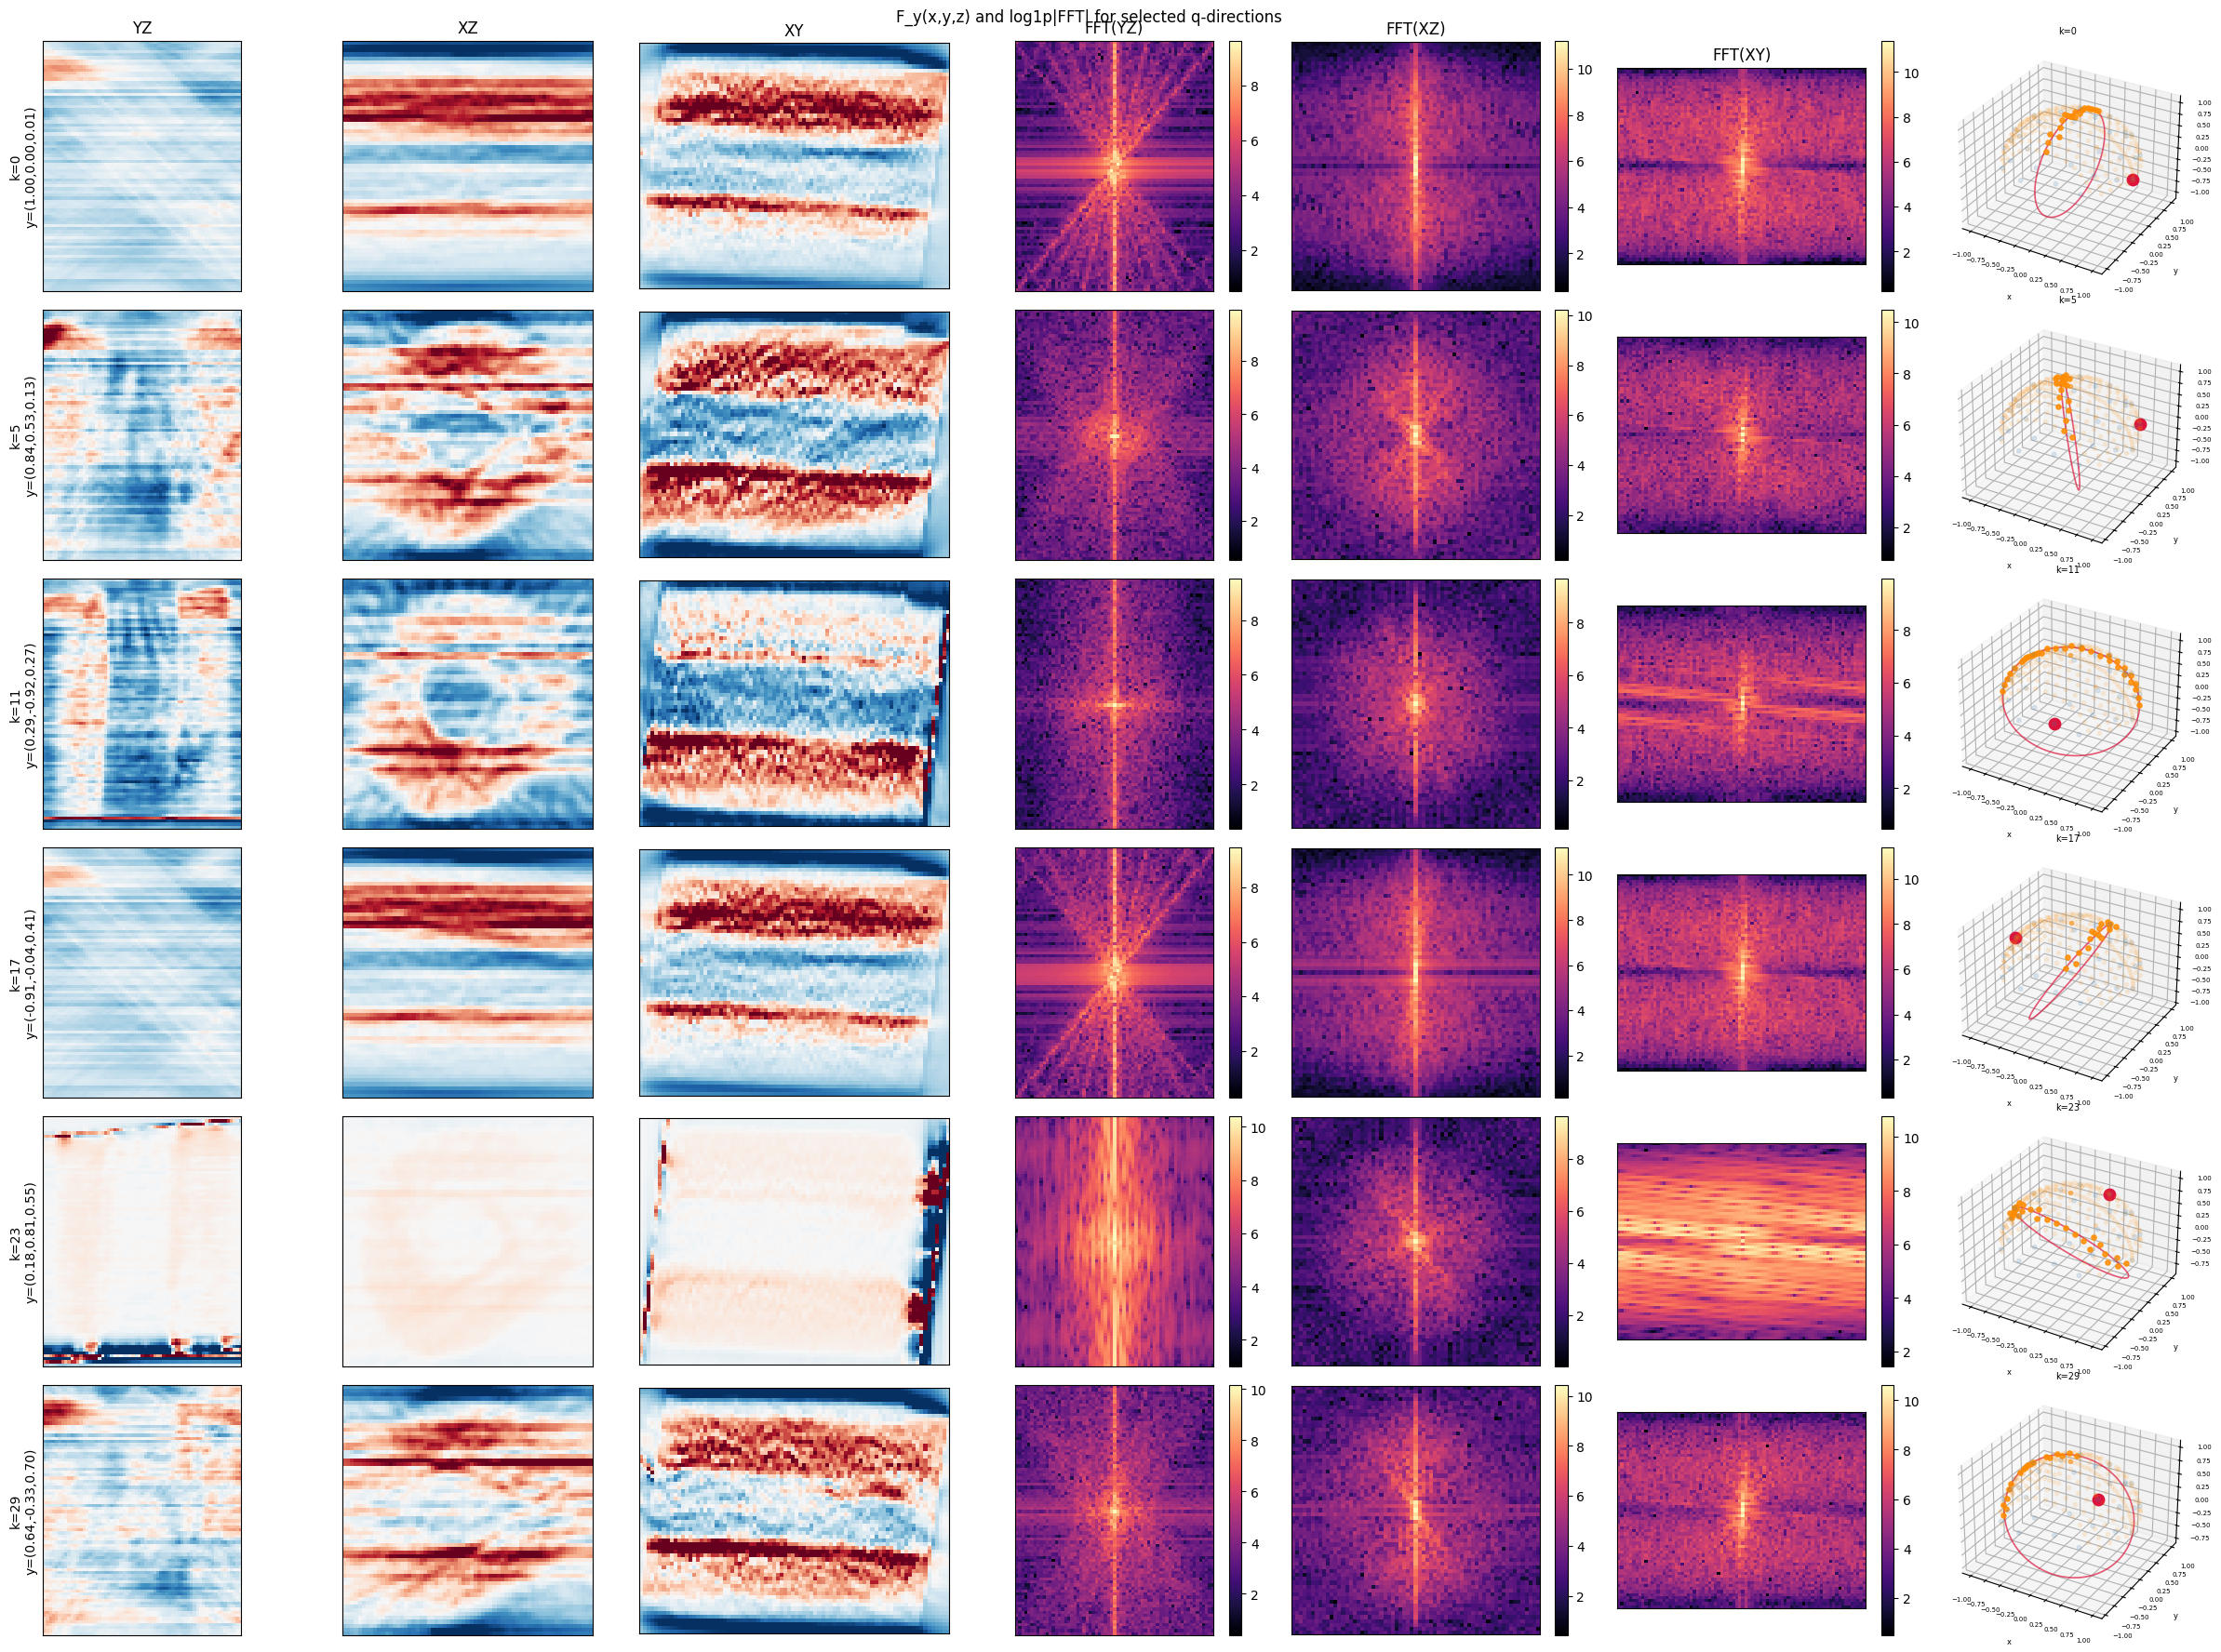

In [37]:
# --- Individual direction volumes for a few representative directions ---
n_show = min(6, K)
dir_indices = np.linspace(0, K - 1, n_show, dtype=int)

def log_fft2(sl):
    return np.log1p(np.abs(np.fft.fftshift(np.fft.fft2(sl))))

fig = plt.figure(figsize=(24, 3 * n_show))
gs = GridSpec(n_show, 7, figure=fig, width_ratios=[1, 1, 1, 1, 1, 1, 0.8])

col_titles = ['YZ', 'XZ', 'XY', 'FFT(YZ)', 'FFT(XZ)', 'FFT(XY)']

for row, k in enumerate(dir_indices):
    vol_k = recon_np[k]   # (X, Y, Z)
    vmin, vmax = np.percentile(vol_k, [2, 98])

    slices = [vol_k[mid_x, :, :], vol_k[:, mid_y, :], vol_k[:, :, mid_z]]
    fft_slices = [log_fft2(sl) for sl in slices]

    for col_idx, sl in enumerate(slices):
        ax = fig.add_subplot(gs[row, col_idx])
        ax.imshow(sl, cmap='RdBu_r', vmin=vmin, vmax=vmax)
        if row == 0:
            ax.set_title(col_titles[col_idx])
        ax.set_xticks([]); ax.set_yticks([])
        if col_idx == 0:
            ax.set_ylabel(f'k={k}\ny=({y_directions[k, 0]:.2f},{y_directions[k, 1]:.2f},{y_directions[k, 2]:.2f})')

    for col_idx, fsl in enumerate(fft_slices):
        ax = fig.add_subplot(gs[row, col_idx + 3])
        im = ax.imshow(fsl, cmap='magma')
        if row == 0:
            ax.set_title(col_titles[col_idx + 3])
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax)

    ax_h = fig.add_subplot(gs[row, 6], projection='3d')
    _hemisphere_ax(ax_h, y_directions, k, contributing=adj[:, k])

plt.suptitle('F_y(x,y,z) and log1p|FFT| for selected q-directions', fontsize=12)
plt.tight_layout()
plt.show()

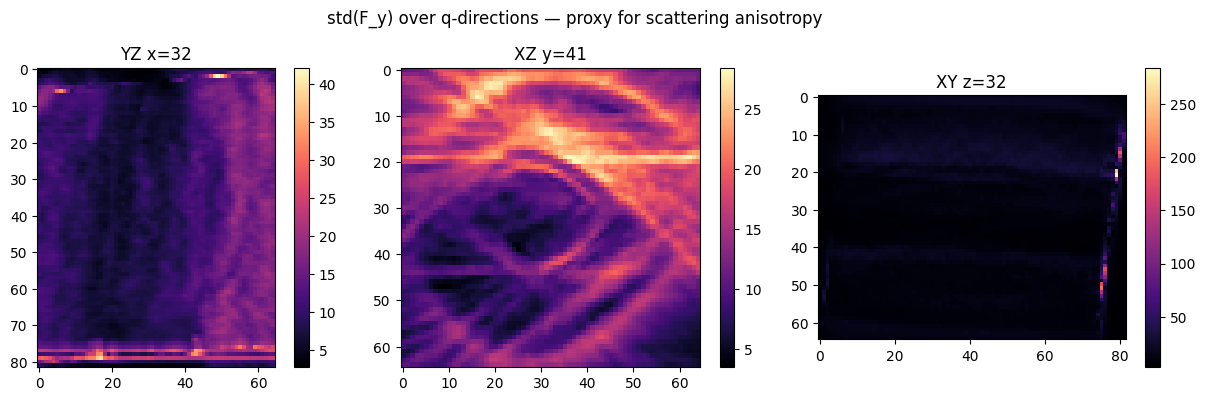

In [14]:
# --- Anisotropy: std over directions (where std is large the signal is anisotropic) ---
std_vol = recon_np.std(axis=0)   # (X, Y, Z)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (sl, title) in zip(axes, [
    (std_vol[mid_x, :, :], f'YZ x={mid_x}'),
    (std_vol[:, mid_y, :], f'XZ y={mid_y}'),
    (std_vol[:, :, mid_z], f'XY z={mid_z}'),
]):
    im = ax.imshow(sl, cmap='magma')
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.suptitle('std(F_y) over q-directions — proxy for scattering anisotropy', fontsize=12)
plt.tight_layout()
plt.show()

## 6. Single-direction deep-dive

Pick one direction and inspect the sub-sinogram going into FBP.

In [15]:
K_INSPECT = 0   # change to inspect other directions

sub_geometry, data_tuple = nn.get_sub_geometry(K_INSPECT, geometry, dc)
data_array, weight_array = data_tuple

N_sub = data_array.shape[0]
print(f'direction k={K_INSPECT}: y = {y_dirs[K_INSPECT].round(3)}')
print(f'contributing projections N_sub = {N_sub}')
print(f'sub-sinogram shape: {data_array.shape}  (N_sub, J, K_det)')
print(f'valid pixels: {(weight_array > 0).mean() * 100:.1f}%')
print(f'data range: [{data_array[weight_array > 0].min():.3e}, {data_array[weight_array > 0].max():.3e}]')

direction k=0: y = [1.    0.    0.002]
contributing projections N_sub = 26
sub-sinogram shape: (26, 73, 100)  (N_sub, J, K_det)
valid pixels: 99.0%
data range: [-8.523e-04, 3.379e+03]


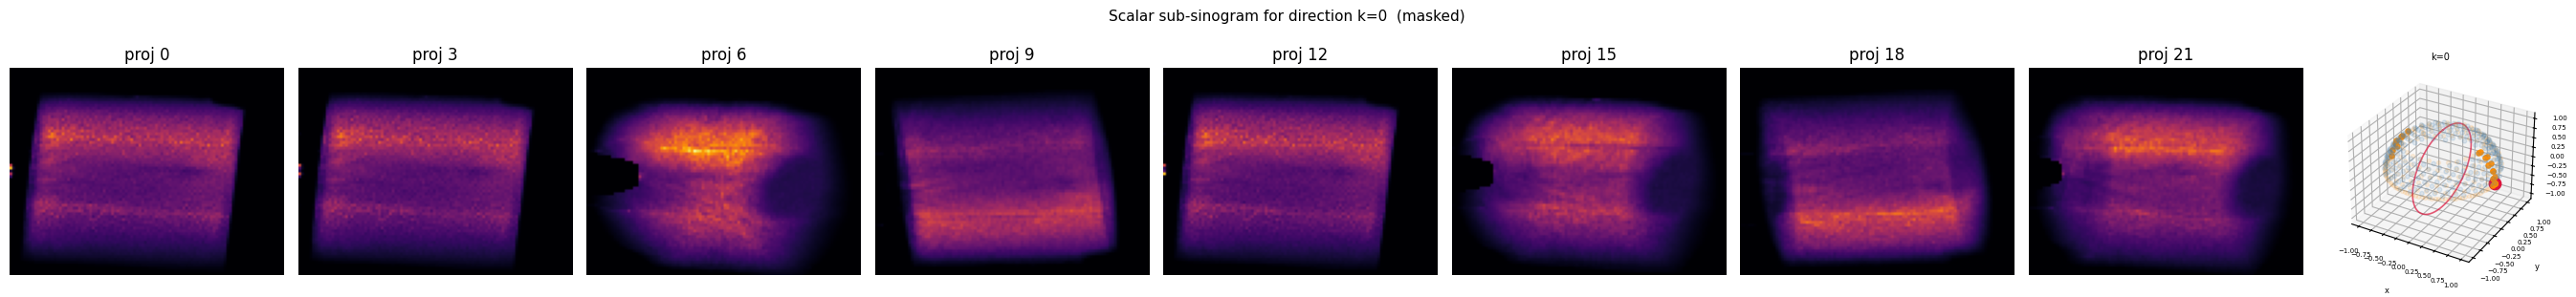

In [16]:
# Show a subset of the sub-sinogram projections
n_show_proj = min(8, N_sub)
proj_step = max(1, N_sub // n_show_proj)
selected = list(range(0, N_sub, proj_step))[:n_show_proj]

valid = (weight_array > 0).astype(data_array.dtype)
sino_masked = data_array * valid
vmin, vmax = sino_masked[valid > 0].min(), sino_masked[valid > 0].max()

fig = plt.figure(figsize=(3 * len(selected) + 3, 3))
gs = GridSpec(1, len(selected) + 1, figure=fig, width_ratios=[1] * len(selected) + [0.9])
axes = [fig.add_subplot(gs[0, i]) for i in range(len(selected))]
ax_h = fig.add_subplot(gs[0, -1], projection='3d')

for ax, n in zip(axes, selected):
    ax.imshow(sino_masked[n], cmap='inferno', vmin=vmin, vmax=vmax, aspect='auto')
    ax.set_title(f'proj {n}')
    ax.axis('off')

_hemisphere_ax(ax_h, y_directions, K_INSPECT, contributing=adj[:, K_INSPECT])

plt.suptitle(f'Scalar sub-sinogram for direction k={K_INSPECT}  (masked)', fontsize=11)
plt.tight_layout()
plt.show()

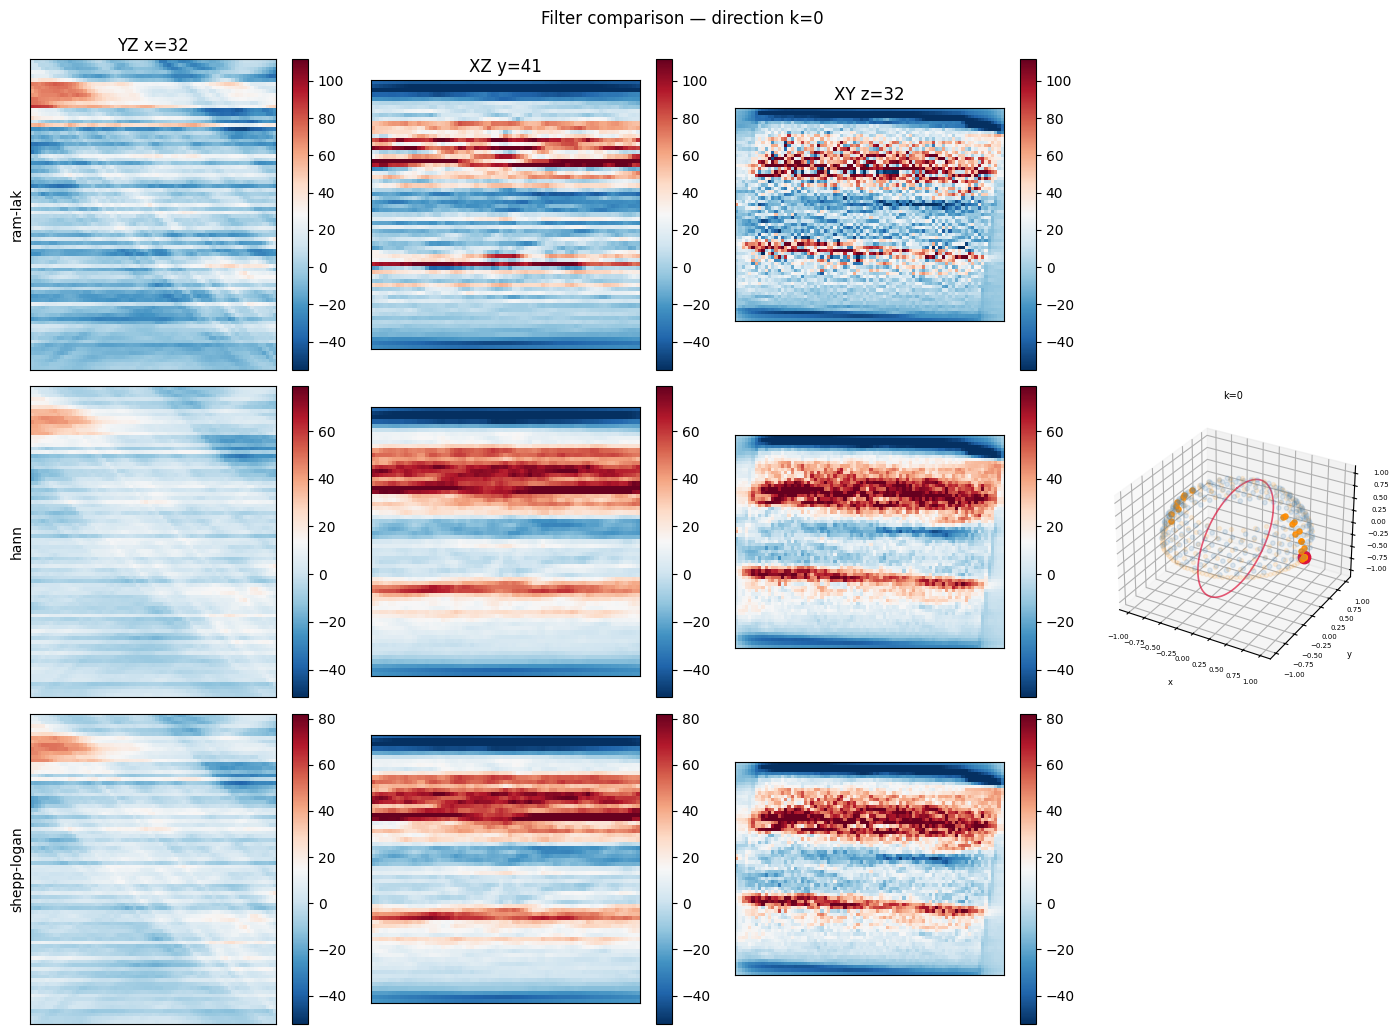

In [17]:
# FBP of just this one direction with ramp filter comparison
sino_t = torch.from_numpy(sino_masked.astype(np.float32)).to(device)

vols = {}
for ft in ['ram-lak', 'hann', 'shepp-logan']:
    vols[ft] = fbp_with_mumott_geometry(
        sino_t, sub_geometry, filter_type=ft, device=device
    ).cpu().numpy()

fig = plt.figure(figsize=(14, 3.5 * len(vols)))
gs = GridSpec(len(vols), 4, figure=fig, width_ratios=[1, 1, 1, 0.8])
ax_h = fig.add_subplot(gs[:, 3], projection='3d')
_hemisphere_ax(ax_h, y_directions, K_INSPECT, contributing=adj[:, K_INSPECT])

for row, (ft, vol) in enumerate(vols.items()):
    vmin, vmax = np.percentile(vol, [2, 98])
    for col, (sl, label) in enumerate([
        (vol[mid_x, :, :], f'YZ x={mid_x}'),
        (vol[:, mid_y, :], f'XZ y={mid_y}'),
        (vol[:, :, mid_z], f'XY z={mid_z}'),
    ]):
        ax = fig.add_subplot(gs[row, col])
        im = ax.imshow(sl, cmap='RdBu_r', vmin=vmin, vmax=vmax)
        ax.set_title(label if row == 0 else '')
        ax.set_ylabel(ft if col == 0 else '')
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax)

plt.suptitle(f'Filter comparison — direction k={K_INSPECT}', fontsize=12)
plt.tight_layout()
plt.show()

## 7. (Optional) Save reconstruction

In [18]:
import pathlib

OUT_DIR = pathlib.Path('/myhome/data/smartt/shared/results/saxs_fbp')
OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = OUT_DIR / f'frogbone_fbp_K{K}.pt'
torch.save({'reconstruction': reconstruction.cpu(), 'y_directions': y_directions}, out_path)
print(f'saved → {out_path}')

saved → /myhome/data/smartt/shared/results/saxs_fbp/frogbone_fbp_K256.pt


## 8. Missing-wedge masks

For each sub-volume k, `missing_wedge_masks` returns a boolean array (shape `X×Y×Z`)
that is `True` where the 3-D Fourier bin lies inside the missing wedge of that sub-CT.

**Derivation**: by the Fourier slice theorem a projection along beam `b` populates the
plane `{q : b·q = 0}` in Fourier space. For sub-CT k the contributing beams are
approximately ⊥ y_k, so the unique beam that would probe frequency q_f is
`b_int = normalize(y_k × q_f)`. That frequency is *missing* when `b_int` falls outside
the accessible polar cap — i.e. `|b_int · p_direction_0| < cos(tilt_max)` —
where `tilt_max` is inferred from the geometry's rotation matrices.

In [19]:
import importlib, math
import smartt.saxs_fbp.reconstruction as _rec_mod
import smartt.saxs_fbp as _fbp_mod
importlib.reload(_rec_mod)
importlib.reload(_fbp_mod)
from smartt.saxs_fbp import missing_wedge_masks

vol_shape = tuple(dc.geometry.volume_shape)
masks = missing_wedge_masks(y_directions, vol_shape, dc.geometry)

# --- diagnostics ---
p0 = np.asarray(dc.geometry.p_direction_0, dtype=float)
p0 /= np.linalg.norm(p0)
outer_angles = np.asarray(list(dc.geometry.outer_angles))
alpha_max = float(np.max(np.abs(outer_angles)))
cos_alpha = math.cos(alpha_max)

print(f'p_direction_0        : {p0.round(4)}')
print(f'alpha_max (tilt)     : {math.degrees(alpha_max):.2f}°')
print(f'cos(alpha_max)       : {cos_alpha:.4f}')
print(f'masks shape          : {masks.shape}  (K, X, Y, Z)')

frac_missing = masks.mean(axis=(1, 2, 3))
print(f'missing fraction per sub-volume:')
print(f'  min={frac_missing.min():.3f}  mean={frac_missing.mean():.3f}  max={frac_missing.max():.3f}')
assert masks.any(), "ERROR: all masks are zero — module reload may have failed"

p_direction_0        : [0. 0. 1.]
alpha_max (tilt)     : 45.00°
cos(alpha_max)       : 0.7071
masks shape          : (256, 65, 82, 65)  (K, X, Y, Z)
missing fraction per sub-volume:
  min=0.501  mean=0.593  max=0.959


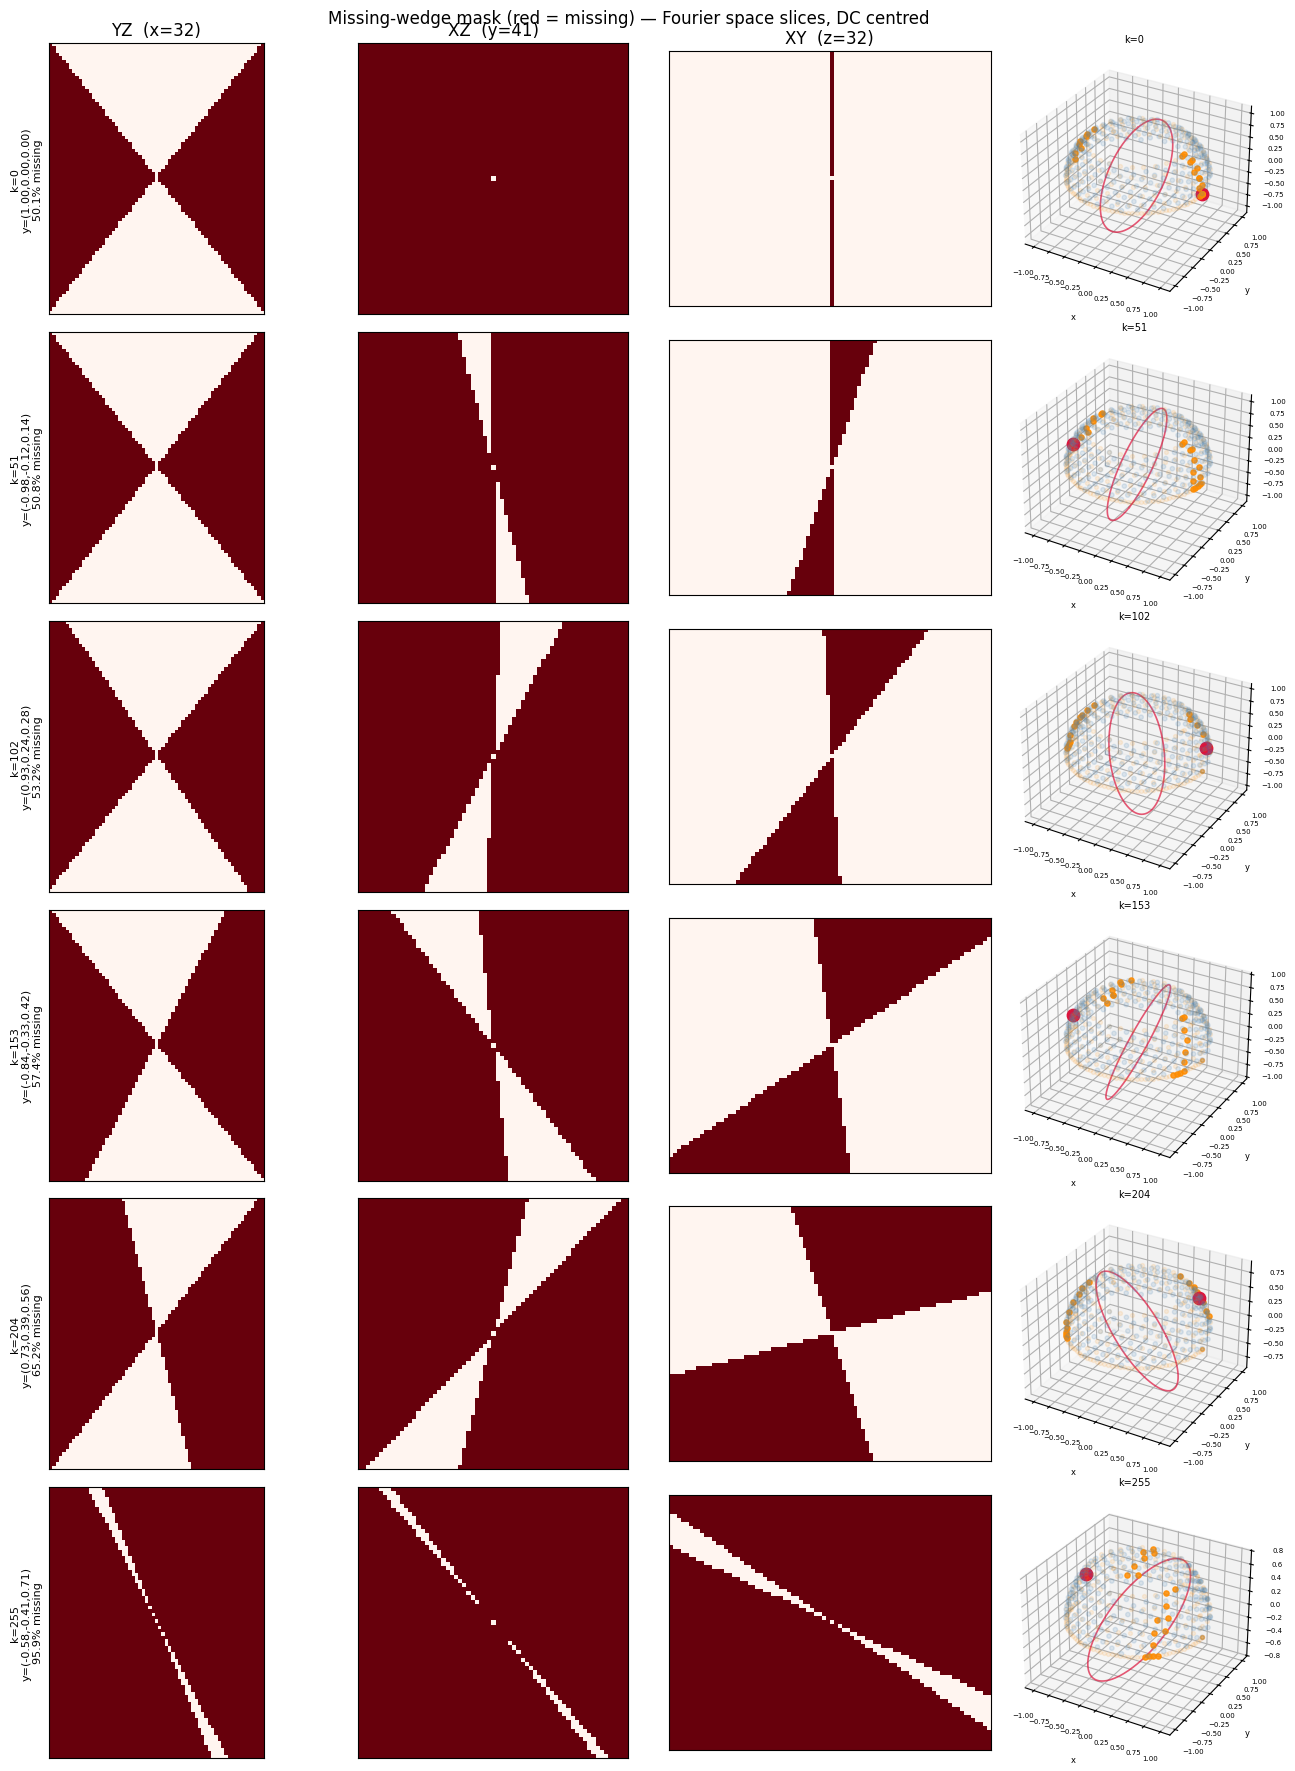

In [20]:
# --- 3 orthogonal Fourier slices of the mask for selected directions ---
n_show = min(6, len(y_directions))
dir_indices = np.linspace(0, len(y_directions) - 1, n_show, dtype=int)

fig = plt.figure(figsize=(13, 3 * n_show))
gs = GridSpec(n_show, 4, figure=fig, width_ratios=[1, 1, 1, 0.8])

col_titles = [f'YZ  (x={mid_x})', f'XZ  (y={mid_y})', f'XY  (z={mid_z})']

for row, k in enumerate(dir_indices):
    mask_k = np.fft.fftshift(masks[k])   # DC at centre
    slices = [mask_k[mid_x, :, :], mask_k[:, mid_y, :], mask_k[:, :, mid_z]]

    yd = y_directions[k]
    for col, sl in enumerate(slices):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(sl, cmap='Reds', vmin=0, vmax=1, origin='lower')
        if row == 0:
            ax.set_title(col_titles[col])
        if col == 0:
            ax.set_ylabel(
                f'k={k}\ny=({yd[0]:.2f},{yd[1]:.2f},{yd[2]:.2f})\n{frac_missing[k]*100:.1f}% missing',
                fontsize=8,
            )
        ax.set_xticks([]); ax.set_yticks([])

    ax_h = fig.add_subplot(gs[row, 3], projection='3d')
    _hemisphere_ax(ax_h, y_directions, k, contributing=adj[:, k])

plt.suptitle('Missing-wedge mask (red = missing) — Fourier space slices, DC centred', fontsize=12)
plt.tight_layout()
plt.show()

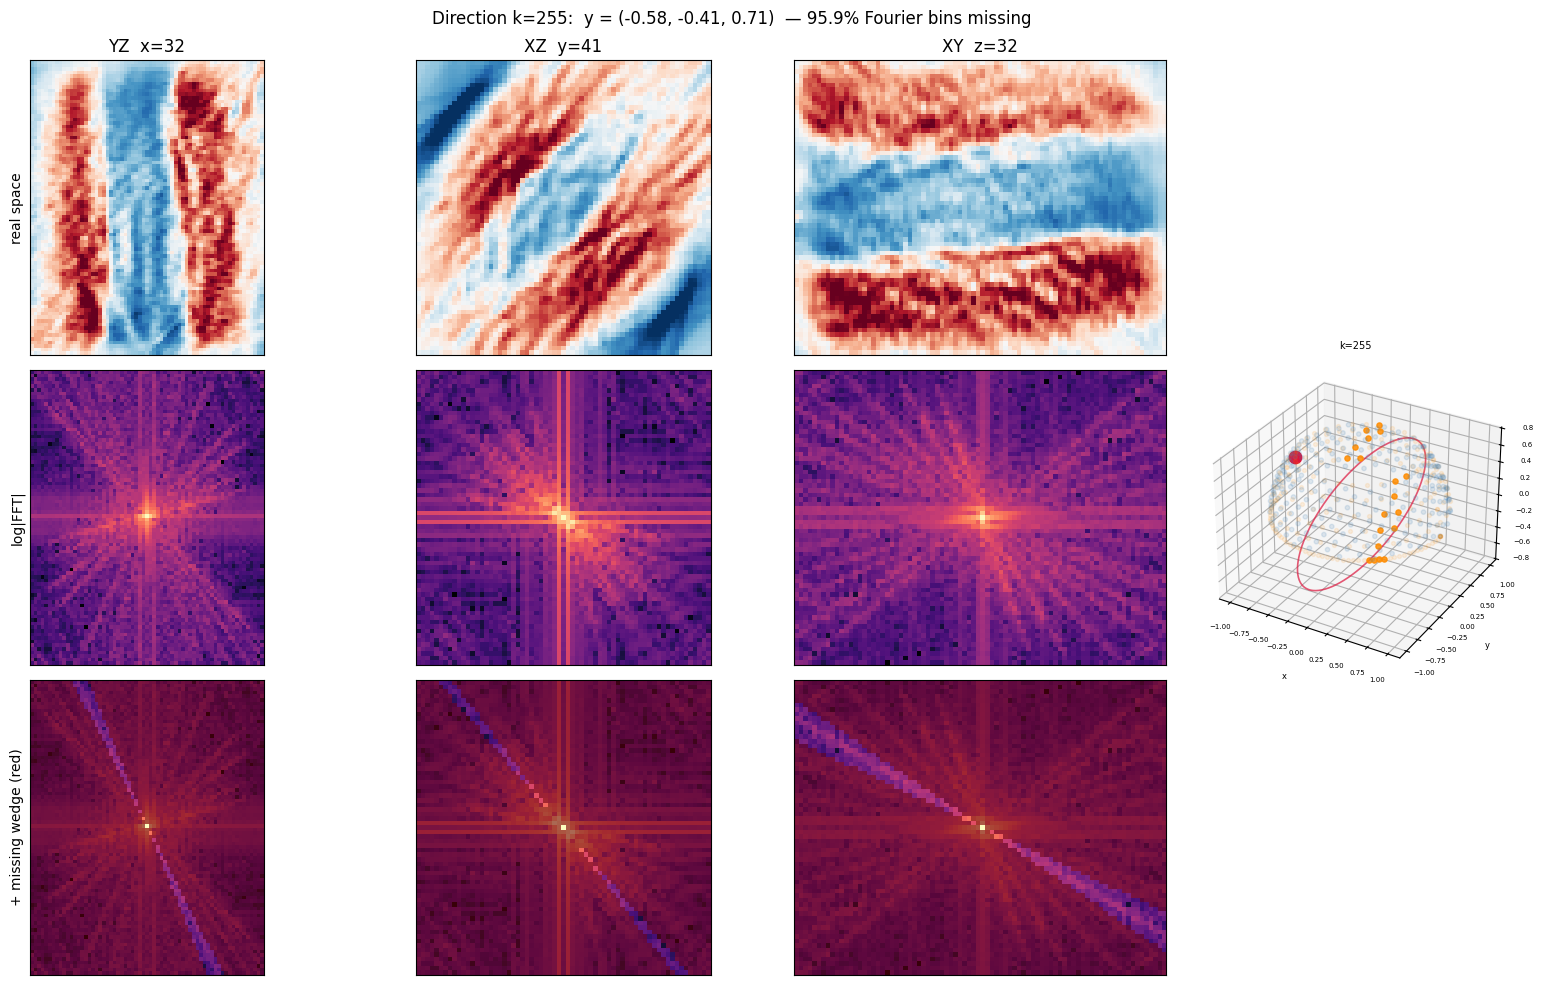

In [21]:
# --- log|FFT| of reconstruction with missing-wedge overlay for one direction ---
K_MASK = dir_indices[len(dir_indices) // 2]   # pick a representative middle direction
K_MASK = 255

vol_k   = recon_np[K_MASK]                                      # (X, Y, Z)
fft_k   = np.fft.fftshift(np.abs(np.fft.fftn(vol_k)))
logfft  = np.log1p(fft_k)
mask_k  = np.fft.fftshift(masks[K_MASK])

real_slices = [
    (vol_k[mid_x, :, :], f'YZ  x={mid_x}'),
    (vol_k[:, mid_y, :], f'XZ  y={mid_y}'),
    (vol_k[:, :, mid_z], f'XY  z={mid_z}'),
]
slice_specs = [
    (logfft[mid_x, :, :], mask_k[mid_x, :, :], f'YZ  x={mid_x}'),
    (logfft[:, mid_y, :], mask_k[:, mid_y, :], f'XZ  y={mid_y}'),
    (logfft[:, :, mid_z], mask_k[:, :, mid_z], f'XY  z={mid_z}'),
]

vmin_r, vmax_r = np.percentile(vol_k, [2, 98])

fig = plt.figure(figsize=(16, 10))
gs = GridSpec(3, 4, figure=fig, width_ratios=[1, 1, 1, 0.8])
ax_h = fig.add_subplot(gs[:, 3], projection='3d')
_hemisphere_ax(ax_h, y_directions, K_MASK, contributing=adj[:, K_MASK])

for col, (sreal, title) in enumerate(real_slices):
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(sreal, cmap='RdBu_r', vmin=vmin_r, vmax=vmax_r, origin='lower')
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    if col == 0:
        ax.set_ylabel('real space', fontsize=10)

for col, (sfft, smask, title) in enumerate(slice_specs):
    ax1 = fig.add_subplot(gs[1, col])
    ax1.imshow(sfft, cmap='magma', origin='lower')
    ax1.set_xticks([]); ax1.set_yticks([])
    if col == 0:
        ax1.set_ylabel('log|FFT|', fontsize=10)

    ax2 = fig.add_subplot(gs[2, col])
    ax2.imshow(sfft, cmap='magma', origin='lower')
    ax2.imshow(np.ma.masked_where(~smask, smask),
               cmap='Reds', alpha=0.55, vmin=0, vmax=1, origin='lower')
    ax2.set_xticks([]); ax2.set_yticks([])
    if col == 0:
        ax2.set_ylabel('+ missing wedge (red)', fontsize=10)

yd = y_directions[K_MASK]
plt.suptitle(
    f'Direction k={K_MASK}:  y = ({yd[0]:.2f}, {yd[1]:.2f}, {yd[2]:.2f})  '
    f'— {frac_missing[K_MASK]*100:.1f}% Fourier bins missing',
    fontsize=12,
)
plt.tight_layout()
plt.show()